#1. Business Problem

Predict Mumbai property prices using
location, property characteristics,
and accessibility metrics.

#2. Data Preparation

In [4]:
import pandas as pd

In [5]:
sales = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Real-Estate-Sales/Data/secondary_sales.csv")

In [6]:
sales.shape


(50000, 32)

In [7]:
sales.head()

,id,date_listed,locality,region,tier,lat,lon,property_type,bedrooms,carpet_area_sqft,...,metro_station,metro_line,metro_distance_min,metro_distance_type,to_bkc_km,to_nariman_point_km,price_inr,price_per_sqft_carpet_inr,price_usd,home_loan_rate_at_listing
0,S000001,2024-11-23,Breach Candy,South Mumbai,luxury,18.96953,72.81853,3BHK,3,1048,...,Grant Road Metro,Line 3,19,walk,12.41,4.82,61694000,58893,740322,9.20
1,S000002,2023-07-05,Breach Candy,South Mumbai,luxury,18.97230,72.81017,2BHK,2,729,...,BKC Metro,Line 3,56,auto/bus,12.55,5.29,40127000,55039,481523,9.20
2,S000003,2022-01-22,Malad East,Western,mid,19.18986,72.85940,2BHK,2,705,...,Dahanukarwadi,Line 2A,19,walk,13.37,29.52,10450000,14813,125398,7.10
3,S000004,2020-11-18,Mulund West,Central,mid,19.15854,72.93798,1BHK,1,424,...,Siddhivinayak,Line 3,90,auto/bus,12.16,28.46,5420000,12781,65036,6.70
4,S000005,2025-01-11,Matunga,Central,premium,19.02358,72.85690,1BHK,1,392,...,Bandra WR,Western Rail,18,auto/bus,5.34,11.35,11713000,29860,140553,8.95


##Feature selection

In [8]:
target = "price_inr"

In [9]:
features = [
    "region",
    "property_type",
    "bedrooms",
    "carpet_area_sqft",
    "floor",
    "year_built",
    "builder_tier",
    "metro_distance_min",
    "to_bkc_km",
    "to_nariman_point_km",
    "furnishing",
    "parking"
]

In [10]:
X = sales[features]
y = sales[target]

In [11]:
X.dtypes

,0
region,object
property_type,object
bedrooms,int64
carpet_area_sqft,int64
floor,int64
year_built,int64
builder_tier,object
metro_distance_min,int64
to_bkc_km,float64
to_nariman_point_km,float64


##Encoding

In [12]:
X = pd.get_dummies(
    X,
    drop_first=True
)

##Train-test split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#3. Baseline Model
##Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)
print("R2:", r2_score(y_test, y_pred))

MAE: 9772174.883975802
RMSE: 15099378.695751376
R2: 0.7019366370936093


A baseline Linear Regression model achieved an R² score of 0.70, indicating that approximately 70% of the variation in property prices can be explained using the selected property and location features.

The model demonstrates good predictive performance for a baseline approach, although prediction errors increase for high-value luxury properties, as reflected by the RMSE metric.

## Model Performance Visualization

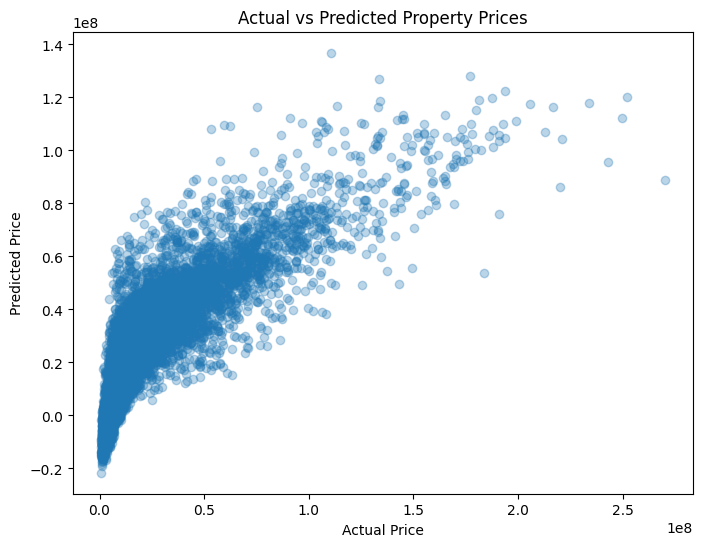

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Property Prices")

plt.show()

The Linear Regression model captures the general relationship between property characteristics and price.

However, prediction accuracy decreases for high-value properties, with the model tending to underestimate luxury listings.

Additionally, some negative predictions were generated, highlighting a limitation of linear regression for real-estate price prediction.

Linear Regression is failing to capture non-linear relationships in premium properties.<br>
So need to go with random forest

#4. Improved Model

##Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred)**0.5)
print("R2:", r2_score(y_test, rf_pred))

MAE: 4771950.732
RMSE: 9514700.577850126
R2: 0.8816466122077689


## Model Performance Visualization

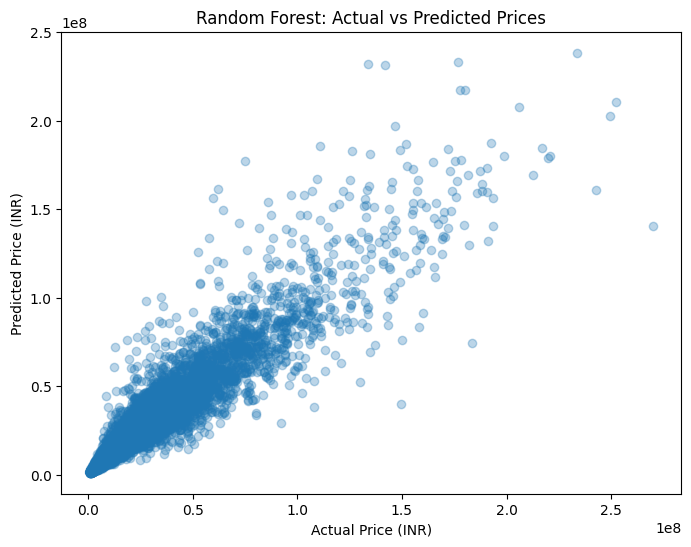

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.3
)

plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")
plt.title("Random Forest: Actual vs Predicted Prices")

plt.show()

The Random Forest model demonstrates a substantially stronger alignment between actual and predicted prices, indicating improved predictive performance and better handling of non-linear relationships.
The Random Forest model demonstrates substantially better predictive performance than Linear Regression, producing a tighter alignment between actual and predicted property prices.

The model effectively captures non-linear relationships and significantly improves predictions for higher-value properties. However, some prediction dispersion remains among luxury listings, indicating the influence of unobserved market factors not included in the dataset.

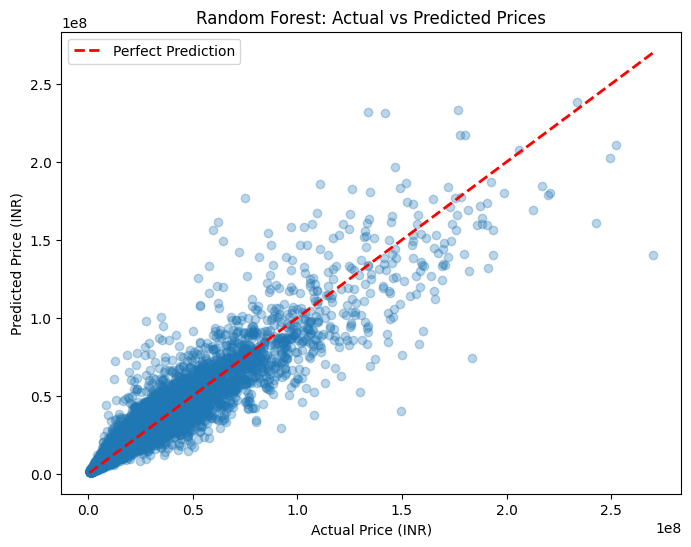

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")
plt.title("Random Forest: Actual vs Predicted Prices")

plt.legend()

plt.show()

## Random Forest: Actual vs Predicted Property Prices

The scatter plot compares actual property prices against prices predicted by the Random Forest model. The red dashed line represents the ideal scenario where predicted values exactly match actual values.

The majority of observations are concentrated close to the ideal prediction line, indicating strong predictive performance. Compared to the baseline Linear Regression model, the Random Forest model demonstrates substantially better alignment between actual and predicted prices, reflecting its ability to capture complex and non-linear relationships within the real estate market.

Prediction accuracy is highest for low and medium-priced properties, where observations closely follow the ideal line. Although some dispersion remains among premium and luxury properties, the model continues to provide reasonable estimates across the full price range.

Overall, the Random Forest model achieved the strongest performance in this project:

- **R² Score:** 0.882
- **MAE:** ₹47.7 Lakh
- **RMSE:** ₹95.1 Lakh

These results indicate that the model explains approximately 88% of the variation in Mumbai property prices and provides a reliable framework for property price prediction.

#5. Model Comparison

In [22]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "R2":[0.702,0.882],
    "MAE":[9772175,4771951],
    "RMSE":[15099379,9514701]
})

comparison

,Model,R2,MAE,RMSE
0,Linear Regression,0.702,9772175,15099379
1,Random Forest,0.882,4771951,9514701


#6. Feature Importance

In [23]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
1,carpet_area_sqft,0.432985
6,to_nariman_point_km,0.332257
5,to_bkc_km,0.119358
0,bedrooms,0.027934
4,metro_distance_min,0.024159
2,floor,0.013738
11,region_Western,0.013076
3,year_built,0.012103
16,builder_tier_tier1,0.007798
9,region_South Mumbai,0.005208


#7. Conclusion

Key Findings
1. Mumbai Property Market Is Highly Segmented

South Mumbai commands the highest property prices and price-per-square-foot values, forming a distinct premium market segment.

2. Builder Reputation Creates a Price Premium

Tier1 builders consistently achieve higher property prices than Tier2 and local builders across all regions.

3. Property Size Is the Strongest Price Driver

Carpet area emerged as the most influential predictor of property value, accounting for approximately 43% of model importance.

4. Proximity to Business Districts Matters

Distance to Nariman Point and BKC collectively account for nearly 45% of predictive importance, highlighting the significance of employment hubs in property valuation.

5. Metro Accessibility Influences Prices

Properties closer to metro stations generally command higher prices, although the effect is weaker than location and size.

6. Random Forest Significantly Outperformed Linear Regression

The final Random Forest model achieved:

R² = 0.882
MAE = ₹47.7 lakh
RMSE = ₹95.1 lakh

compared to:

R² = 0.702 for Linear Regression